# Load Dataset

In [14]:
# ── Standard library ──────────────────────────────────────────────────────────
import importlib.util
import json
import os
import sys
from collections import Counter
from pathlib import Path

# ── Third-party ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from lightgbm import Booster, LGBMClassifier
from matplotlib.colors import LogNorm
from sklearn import multiclass
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# ── Project source modules ─────────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

def _load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

sleep_data_utils = _load_module("sleep_data_utils", SRC_DIR / "sleep_data_utils.py")
sleep_model_utils = _load_module("sleep_model_utils", SRC_DIR / "sleep_model_utils.py")


DEFAULT_STAGE_MAP = sleep_data_utils.DEFAULT_STAGE_MAP
SleepDataset = sleep_data_utils.SleepDataset
build_subject_list = sleep_data_utils.build_subject_list
encode_labels = sleep_data_utils.encode_labels
flatten_dataset = sleep_data_utils.flatten_dataset
load_sleep_config = sleep_data_utils.load_sleep_config
load_or_create_subject_split = sleep_data_utils.load_or_create_subject_split
render_subject_split_file_template = sleep_data_utils.render_subject_split_file_template

plot_confusion_matrix = sleep_model_utils.plot_confusion_matrix


# ── Config ─────────────────────────────────────────────────────────────────────
CONFIG_PATH = PROJECT_ROOT / "config" / "sleep-model.yaml"
cfg = load_sleep_config(CONFIG_PATH)

SMALL_BATCH_TEST = cfg["subjects"]["small_batch_test"]
FEAT_COLS = cfg["data"]["feature_cols"]
TARGET_COL = cfg["data"]["target_cols"]
FEAT_METADATA_COLS = cfg["data"]["feature_metadata_cols"]
STAGE_MAP = cfg.get("labels", {}).get("stage_map", DEFAULT_STAGE_MAP)

SIGNAL_DIR = str((CONFIG_PATH.parent / cfg["data"]["signal_dir"]).resolve())
METADATA_CSV = str((CONFIG_PATH.parent / cfg["data"]["metadata_csv"]).resolve())

ACROSS_SUBJECT_RATIO = cfg["split"]["across_subject_ratio"]
subject_split_template = cfg["split"].get(
    "subject_split_file",
    "../data/processed/splits/subject_split_seed{seed}_ratio_{ratio_tag}.json",
)
SPLIT_FILE = str((
    CONFIG_PATH.parent / render_subject_split_file_template(
        subject_split_template,
        seed=cfg["split"]["seed"],
        ratio=ACROSS_SUBJECT_RATIO,
    )
).resolve())

SUBJECTS = build_subject_list(
    prefix=cfg["subjects"]["prefix"],
    start=cfg["subjects"]["start"],
    end=cfg["subjects"]["end"],
    small_batch_test=SMALL_BATCH_TEST,
    small_batch_limit=cfg["subjects"]["small_batch_limit"],
)

In [2]:
# Build/load subject split using config seed + ratio
split_payload = load_or_create_subject_split(
    subject_ids=SUBJECTS,
    split_file_path=SPLIT_FILE,
    ratio=cfg["split"].get("across_subject_ratio", cfg["split"]["within_subject_ratio"]),
    seed=cfg["split"]["seed"],
)

train_subs = split_payload["train_subjects"]
val_subs = split_payload["val_subjects"]
test_subs = split_payload["test_subjects"]

print(f"Loaded split file: {SPLIT_FILE}")
print(f"Subjects => train: {len(train_subs)}, val: {len(val_subs)}, test: {len(test_subs)}")

train_ds = SleepDataset(
    signals_dir=SIGNAL_DIR,
    metadata_csv=METADATA_CSV,
    feature_cols=FEAT_COLS,
    label_cols=TARGET_COL,
    allowed_subjects=train_subs,
    block_duration_sec=cfg["dataset"]["block_duration_sec"],
    epoch_sec=cfg["dataset"]["epoch_sec"],
    drop_boundary=cfg["dataset"]["drop_boundary"],
    meta_feature_cols=FEAT_METADATA_COLS,
)

val_ds = SleepDataset(
    signals_dir=SIGNAL_DIR,
    metadata_csv=METADATA_CSV,
    feature_cols=FEAT_COLS,
    label_cols=TARGET_COL,
    allowed_subjects=val_subs,
    block_duration_sec=cfg["dataset"]["block_duration_sec"],
    epoch_sec=cfg["dataset"]["epoch_sec"],
    drop_boundary=cfg["dataset"]["drop_boundary"],
    meta_feature_cols=FEAT_METADATA_COLS,
)

test_ds = SleepDataset(
    signals_dir=SIGNAL_DIR,
    metadata_csv=METADATA_CSV,
    feature_cols=FEAT_COLS,
    label_cols=TARGET_COL,
    allowed_subjects=test_subs,
    block_duration_sec=cfg["dataset"]["block_duration_sec"],
    epoch_sec=cfg["dataset"]["epoch_sec"],
    drop_boundary=cfg["dataset"]["drop_boundary"],
    meta_feature_cols=FEAT_METADATA_COLS,
)

X_train, y_train, info_train = flatten_dataset(train_ds)
X_val, y_val, info_val = flatten_dataset(val_ds)
X_test, y_test, info_test = flatten_dataset(test_ds)

X_train, y_train, info_train = encode_labels(X_train, y_train, info_train, stage_map=STAGE_MAP)
X_val, y_val, info_val = encode_labels(X_val, y_val, info_val, stage_map=STAGE_MAP)
X_test, y_test, info_test = encode_labels(X_test, y_test, info_test, stage_map=STAGE_MAP)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape} | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape} | y_test shape:  {y_test.shape}")

Loaded split file: /mnt/oneTB/spring-2026-real-time-sleep-stage-estimation/data/processed/splits/subject_split_seed42_ratio_64_16_20.json
Subjects => train: 66, val: 16, test: 20
X_train shape: (294283, 214) | y_train shape: (294283,)
X_val shape:   (74544, 214) | y_val shape:   (74544,)
X_test shape:  (86975, 214) | y_test shape:  (86975,)


In [3]:
print(f"Signal features:   {len(FEAT_COLS)}")
print(f"Metadata features: {len(FEAT_METADATA_COLS)}")
print(f"Total input dim:   {len(FEAT_COLS) + len(FEAT_METADATA_COLS)}")

print("\nClass distribution (train):")
values, counts = np.unique(y_train, return_counts=True)
labels = [k for k, _ in sorted(STAGE_MAP.items(), key=lambda kv: kv[1])]
for v, c in zip(values, counts):
    print(f"  {labels[v]}: {c} ({c / counts.sum():.2%})")

Signal features:   198
Metadata features: 16
Total input dim:   214

Class distribution (train):
  W: 76949 (26.15%)
  N1: 32812 (11.15%)
  N2: 146338 (49.73%)
  N3: 9702 (3.30%)
  R: 28482 (9.68%)


# Feature Engineering

## add power ratios / lag features

In [4]:
def add_core_sleep_ratios_df(X, ratio_cols, original_cols=None, eps=1e-6):
    """
    Add relative band-power and ratio features for each EEG channel.

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
    ratio_cols : list[str]   EEG channel prefixes, e.g. ["eeg_c4", "eeg_f4"]
    original_cols : list[str] or None
        Column names for X.  Defaults to FEAT_COLS + FEAT_METADATA_COLS.
    """
    if original_cols is None:
        original_cols = FEAT_COLS + FEAT_METADATA_COLS

    df = pd.DataFrame(X, columns=original_cols)

    for ch in ratio_cols:
        delta = df[f"{ch}_bp_delta"]
        theta = df[f"{ch}_bp_theta"]
        alpha = df[f"{ch}_bp_alpha"]
        sigma = df[f"{ch}_bp_sigma"]
        beta  = df[f"{ch}_bp_beta"]

        total = delta + theta + alpha + sigma + beta

        df[f"{ch}_bp_delta_rel"] = delta / (total + eps)
        df[f"{ch}_bp_theta_rel"] = theta / (total + eps)
        df[f"{ch}_bp_alpha_rel"] = alpha / (total + eps)
        df[f"{ch}_bp_sigma_rel"] = sigma / (total + eps)
        df[f"{ch}_bp_beta_rel"]  = beta  / (total + eps)

        df[f"{ch}_bp_delta_over_theta"] = delta / (theta + eps)
        df[f"{ch}_bp_delta_over_alpha"] = delta / (alpha + eps)
        df[f"{ch}_bp_theta_over_alpha"] = theta / (alpha + eps)
        df[f"{ch}_bp_sigma_over_delta"] = sigma / (delta + eps)

    return df.to_numpy(dtype=np.float32), df.columns.tolist()

In [5]:
def add_lag_features(X, feature_names, lag_features, lags=(1, 2, 3)):
    """
    Add lag features to selected columns.
    """
    df = pd.DataFrame(X, columns=feature_names)

    for col in lag_features:
        if col not in df.columns:
            raise ValueError(f"{col} not found in feature_names")
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

    keep_idx = np.arange(max(lags), len(df))
    df = df.iloc[keep_idx].reset_index(drop=True)

    feature_names_new = df.columns.tolist()
    X_new = df.to_numpy(dtype=np.float32)

    return X_new, feature_names_new, keep_idx

In [6]:
eeg_channels = ["eeg_c4", "eeg_f4", "eeg_o2", "eeg_fp1", "eeg_t3", "eeg_cz"]

lag_features = [
    "eeg_c4_bp_delta",
    "eeg_o2_bp_theta",
    "eog_e2_bp_slow",
    "eeg_cz_bp_delta",
    "eeg_cz_bp_high_gamma",
    "hr_mean",
    "temp_mean",
]
lag_shifts = (1,2,3)


X_train_aug, feature_names_aug0 = add_core_sleep_ratios_df(X_train, ratio_cols=eeg_channels)
X_val_aug, _ = add_core_sleep_ratios_df(X_val, ratio_cols=eeg_channels)
X_test_aug, _ = add_core_sleep_ratios_df(X_test, ratio_cols=eeg_channels)


print("Original train:", X_train.shape)
print("Added power ratio train:", X_train_aug.shape)

X_train_aug, feature_names_aug, keep_idx = add_lag_features(
    X_train_aug,
    feature_names=feature_names_aug0,
    lag_features=lag_features,
    lags=lag_shifts,
)
y_train_aug = y_train[keep_idx]
info_train_aug = info_train.iloc[keep_idx].reset_index(drop=True)

X_val_aug, _, keep_idx = add_lag_features(
    X_val_aug,
    feature_names=feature_names_aug0,
    lag_features=lag_features,
    lags=lag_shifts,
)
y_val_aug = y_val[keep_idx]
info_val_aug = info_val.iloc[keep_idx].reset_index(drop=True)

X_test_aug, _, keep_idx = add_lag_features(
    X_test_aug,
    feature_names=feature_names_aug0,
    lag_features=lag_features,
    lags=lag_shifts,
)
y_test_aug = y_test[keep_idx]
info_test_aug = info_test.iloc[keep_idx].reset_index(drop=True)

print(f"Added {len(lag_shifts)} lags :", X_train_aug.shape)
print("new features:", feature_names_aug)

Original train: (294283, 214)
Added power ratio train: (294283, 268)
Added 3 lags : (294280, 289)
new features: ['eeg_c4_mean', 'eeg_c4_std', 'eeg_c4_min', 'eeg_c4_max', 'eeg_c4_range', 'eeg_c4_slope', 'eeg_f4_mean', 'eeg_f4_std', 'eeg_f4_min', 'eeg_f4_max', 'eeg_f4_range', 'eeg_f4_slope', 'eeg_o2_mean', 'eeg_o2_std', 'eeg_o2_min', 'eeg_o2_max', 'eeg_o2_range', 'eeg_o2_slope', 'eeg_fp1_mean', 'eeg_fp1_std', 'eeg_fp1_min', 'eeg_fp1_max', 'eeg_fp1_range', 'eeg_fp1_slope', 'eeg_t3_mean', 'eeg_t3_std', 'eeg_t3_min', 'eeg_t3_max', 'eeg_t3_range', 'eeg_t3_slope', 'eeg_cz_mean', 'eeg_cz_std', 'eeg_cz_min', 'eeg_cz_max', 'eeg_cz_range', 'eeg_cz_slope', 'eog_e1_mean', 'eog_e1_std', 'eog_e1_min', 'eog_e1_max', 'eog_e1_range', 'eog_e1_slope', 'eog_e2_mean', 'eog_e2_std', 'eog_e2_min', 'eog_e2_max', 'eog_e2_range', 'eog_e2_slope', 'emg_chin_mean', 'emg_chin_std', 'emg_chin_min', 'emg_chin_max', 'emg_chin_range', 'emg_chin_slope', 'emg_lat_mean', 'emg_lat_std', 'emg_lat_min', 'emg_lat_max', 'emg_la

In [7]:
# override
X_train = X_train_aug
y_train = y_train_aug
info_train = info_train_aug
X_val = X_val_aug
y_val = y_val_aug
info_val = info_val_aug
X_test = X_test_aug
y_test = y_test_aug
info_test = info_test_aug

# Model train and eval

## Logistic Regression

In [ ]:
c_list = [0.01, 1.0, 100.0]

for c in c_list:
    logreg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
                    max_iter=2000,
                    solver="lbfgs",
                    class_weight="balanced",
                    C=c,
                    random_state=42,
                ))
    ])

    logreg.fit(X_train, y_train)
    val_pred = logreg.predict(X_val)

    print("Val macro F1:", f1_score(y_val, val_pred, average="macro"), " for C=", c)
    print(classification_report(y_val, val_pred, digits=4, target_names=["W","N1","N2","N3","R"]))
    print("===================")

Val macro F1: 0.430108633787947  for C= 100.0
              precision    recall  f1-score   support

           W     0.7262    0.4444    0.5514     19218
          N1     0.1944    0.2603    0.2226      7356
          N2     0.8338    0.5226    0.6425     39336
          N3     0.1775    0.6841    0.2818      3090
           R     0.3253    0.7417    0.4522      8454

    accuracy                         0.5087     77454
   macro avg     0.4514    0.5306    0.4301     77454
weighted avg     0.6647    0.5087    0.5449     77454



As C increases, regularizations are weaker. Increased score for weaker means that model can benifit from having many weaker signals. It also means that logistic regression tends to underfit for the given data. 

## XGBoost

In [50]:
def objective_xgb(trial, X, y, groups, n_splits=4, class_weight=None):
    params = {
        "objective": "multi:softprob",
        "num_class": 5,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,

        "n_estimators": trial.suggest_int("n_estimators", 300, 900),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
    }

    cv = GroupKFold(n_splits=n_splits)
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups), start=1):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        w_tr = compute_sample_weight(class_weight="balanced", y=y_tr)

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, sample_weight=w_tr)

        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average="macro")
        fold_scores.append(score)

        trial.report(np.mean(fold_scores), step=fold)
        print(f"[Trial {trial.number}] Fold {fold} | F1: {score:.4f} | Mean: {np.mean(fold_scores):.4f}")

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

In [51]:
groups = info_train["subject_id"].values

optuna.logging.set_verbosity(optuna.logging.INFO)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)

study.optimize(
    lambda trial: objective_xgb(trial, X_train, y_train, groups),
    n_trials=30,
    show_progress_bar=True,
)

print("Best trial score:", study.best_value)
print("Best params:")
print(study.best_params)

[I 2026-03-23 12:04:47,164] A new study created in memory with name: no-name-78e8094d-9c43-48c8-b44b-92510e78e6e7


  0%|          | 0/30 [00:00<?, ?it/s]

[Trial 0] Fold 1 | F1: 0.6127 | Mean: 0.6127
[Trial 0] Fold 2 | F1: 0.6092 | Mean: 0.6109
[Trial 0] Fold 3 | F1: 0.5592 | Mean: 0.5937
[Trial 0] Fold 4 | F1: 0.6177 | Mean: 0.5997
[I 2026-03-23 12:29:55,416] Trial 0 finished with value: 0.599681285719073 and parameters: {'n_estimators': 525, 'max_depth': 7, 'learning_rate': 0.07423898007815308, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'min_child_weight': 1, 'gamma': 0.11616722433639892, 'reg_alpha': 0.29154431891537513, 'reg_lambda': 0.16730402817820234}. Best is trial 0 with value: 0.599681285719073.
[Trial 1] Fold 1 | F1: 0.6302 | Mean: 0.6302
[Trial 1] Fold 2 | F1: 0.5998 | Mean: 0.6150
[Trial 1] Fold 3 | F1: 0.5799 | Mean: 0.6033
[Trial 1] Fold 4 | F1: 0.6209 | Mean: 0.6077
[I 2026-03-23 12:46:36,062] Trial 1 finished with value: 0.6076954915179111 and parameters: {'n_estimators': 725, 'max_depth': 3, 'learning_rate': 0.11370159575730848, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7637017

In [59]:
best_params = study.best_params.copy()
best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params,
)

best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_val)
print("Val macro F1:", f1_score(y_val, y_pred, average="macro"))
print(classification_report(
    y_val, y_pred, digits=4,
    target_names=["W", "N1", "N2", "N3", "R"]
))
val_pred=y_pred

Val macro F1: 0.6677336408815309
              precision    recall  f1-score   support

           W     0.8741    0.8556    0.8647     19215
          N1     0.4491    0.2995    0.3594      7356
          N2     0.8230    0.9412    0.8782     39336
          N3     0.7513    0.3754    0.5006      3090
           R     0.7997    0.6813    0.7358      8454

    accuracy                         0.8081     77451
   macro avg     0.7394    0.6306    0.6677     77451
weighted avg     0.7947    0.8081    0.7949     77451



In [ ]:
# save model
exp_dir = Path("../models/xgb_featured")
exp_dir.mkdir(parents=True, exist_ok=True)

best_xgb.save_model(exp_dir / "model.json")

artifact = {
    "best_params": study.best_params,
    "best_cv_score": float(study.best_value),
    "feature_cols": feature_names_aug,
}
with open(exp_dir / "metadata.json", "w") as f:
    json.dump(artifact, f, indent=2)

print(f"Saved XGBoost to {exp_dir}")

In [54]:
importance = best_xgb.feature_importances_
feat_imp = pd.Series(importance, index=feature_names_aug).sort_values(ascending=False)
feat_imp.head(20)

eeg_c4_bp_delta_over_alpha    0.088881
eeg_c4_bp_delta_rel           0.061023
eeg_cz_bp_delta_over_alpha    0.050808
eeg_cz_bp_delta_over_theta    0.028016
eeg_c4_bp_beta                0.025533
eeg_t3_bp_delta_over_alpha    0.023192
eeg_c4_bp_delta_over_theta    0.021544
eeg_c4_bp_beta_rel            0.021284
eeg_cz_bp_delta_rel           0.020680
eeg_f4_bp_alpha               0.019061
eeg_c4_bp_delta               0.018688
eeg_t3_bp_delta_over_theta    0.017277
eeg_cz_bp_delta               0.014515
eeg_f4_bp_alpha_rel           0.012256
eeg_c4_bp_delta_lag3          0.011374
eeg_f4_bp_delta_over_alpha    0.010308
eog_e2_bp_slow                0.010062
eeg_fp1_bp_gamma              0.009806
eeg_t3_bp_delta_rel           0.008944
eog_e1_bp_slow                0.008369
dtype: float32

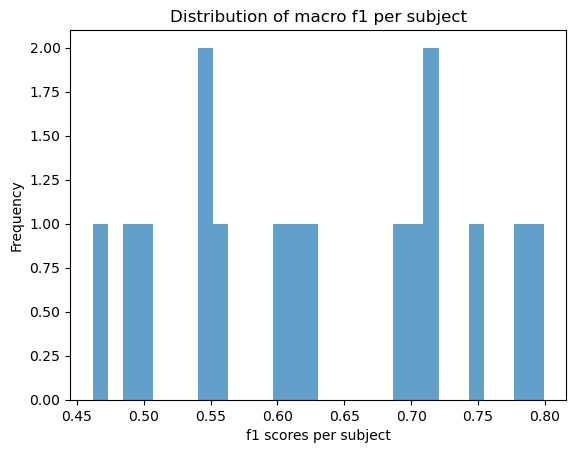

In [ ]:
val_df = info_val.copy()
val_df["y_true"] = y_val
val_df["y_pred"] = val_pred
scores = []
for sid, g in val_df.groupby("subject_id"):
    scores.append(f1_score(g.y_true, g.y_pred, average="macro"))
plt.hist(scores, bins=30, alpha=0.7)
plt.xlabel("f1 scores per subject")
plt.ylabel("Frequency")
plt.title("Distribution of macro F1 per subject")
plt.show()

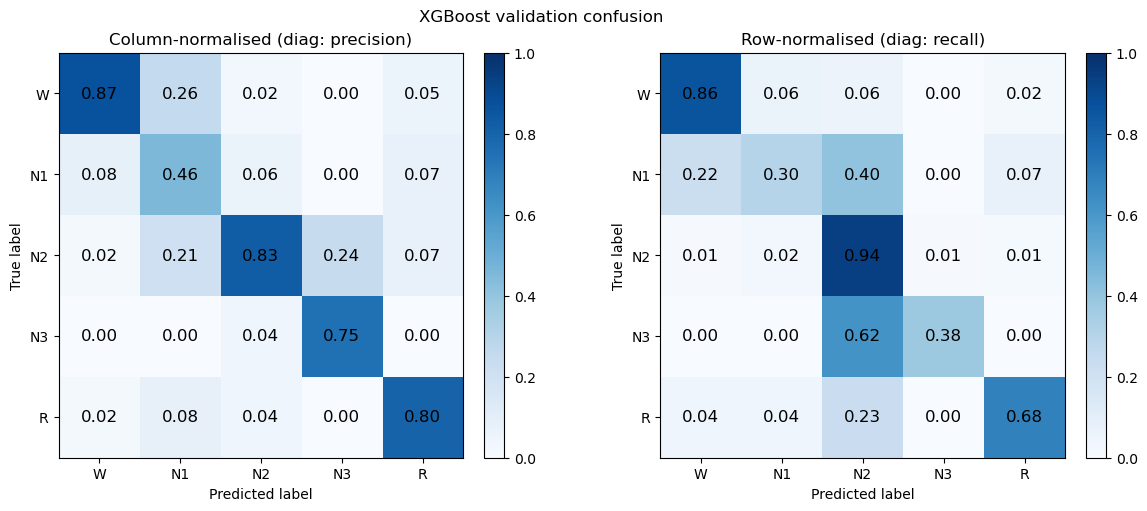

In [17]:
cm = {"confusion_matrix":confusion_matrix(y_val,y_pred_xgb)}
plot_confusion_matrix(cm, STAGE_MAP, title="XGBoost validation confusion")

## LightGBM

In [34]:
def objective_lgb(trial, X, y, groups, n_splits=4, class_weight=None):
    params = {
        "objective": "multiclass",
        "num_class": 5,
        "metric": "multi_logloss",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,

        "n_estimators": trial.suggest_int("n_estimators", 300, 900),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 96),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 3, 4, 5, 6, 8]),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
    }

    cv = GroupKFold(n_splits=n_splits)
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups), start=1):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        w_tr = w_tr = compute_sample_weight(class_weight="balanced", y=y_tr)

        model = LGBMClassifier(**params)
        model.fit(X_tr, y_tr, sample_weight=w_tr)

        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average="macro")
        fold_scores.append(score)

        trial.report(np.mean(fold_scores), step=fold)
        print(f"[Trial {trial.number}] Fold {fold} | F1: {score:.4f} | Mean: {np.mean(fold_scores):.4f}")

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

In [35]:
groups = info_train["subject_id"].values

optuna.logging.set_verbosity(optuna.logging.INFO)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)

study.optimize(
    lambda trial: objective_lgb(trial, X_train, y_train, groups),
    n_trials=50,
    show_progress_bar=True,
)

print("Best trial score:", study.best_value)
print("Best params:")
print(study.best_params)

[I 2026-03-23 02:11:06,844] A new study created in memory with name: no-name-93dfea90-9584-47a0-b81a-2f5b0358fcdd


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/adiacheng1/miniconda3/envs/sleep_stage/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Trial 0] Fold 1 | F1: 0.5788 | Mean: 0.5788


/Users/adiacheng1/miniconda3/envs/sleep_stage/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[Trial 49] Fold 2 | F1: 0.6107 | Mean: 0.6258


/Users/adiacheng1/miniconda3/envs/sleep_stage/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Trial 49] Fold 3 | F1: 0.5876 | Mean: 0.6130


/Users/adiacheng1/miniconda3/envs/sleep_stage/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Trial 49] Fold 4 | F1: 0.6287 | Mean: 0.6170
[I 2026-03-23 07:11:59,213] Trial 49 finished with value: 0.6169538146322695 and parameters: {'n_estimators': 692, 'learning_rate': 0.02809020756036191, 'num_leaves': 27, 'max_depth': 6, 'min_child_samples': 28, 'subsample': 0.7015085630279064, 'colsample_bytree': 0.7942634112439968, 'reg_alpha': 0.015190911528483245, 'reg_lambda': 1.178587036485624, 'min_split_gain': 0.12079460990682249}. Best is trial 45 with value: 0.6230414244208621.
Best trial score: 0.6230414244208621
Best params:
{'n_estimators': 507, 'learning_rate': 0.028837998485710736, 'num_leaves': 55, 'max_depth': 6, 'min_child_samples': 30, 'subsample': 0.709720720637972, 'colsample_bytree': 0.769265949975664, 'reg_alpha': 0.0018034674743147227, 'reg_lambda': 3.737637699731791, 'min_split_gain': 0.23522874405283256}


In [ ]:
best_params = study.best_params.copy()

best_lgb = LGBMClassifier(
    objective="multiclass",
    num_class=5,
    metric="multi_logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **best_params,
)

best_lgb.fit(X_train, y_train)

y_pred = best_lgb.predict(X_val)

print("Val macro F1:", f1_score(y_val, y_pred, average="macro"))
print(classification_report(
    y_val, y_pred, digits=4,
    target_names=["W", "N1", "N2", "N3", "R"]
))

/Users/adiacheng1/miniconda3/envs/sleep_stage/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Val macro F1: 0.6538234159439131
              precision    recall  f1-score   support

           W     0.8715    0.8526    0.8619     19215
          N1     0.4333    0.3191    0.3675      7356
          N2     0.8216    0.9377    0.8759     39336
          N3     0.6785    0.3204    0.4353      3090
           R     0.8117    0.6609    0.7286      8454

    accuracy                         0.8030     77451
   macro avg     0.7233    0.6181    0.6538     77451
weighted avg     0.7903    0.8030    0.7905     77451



In [ ]:
# save model
exp_dir = Path("../models/lgb_featured")
exp_dir.mkdir(parents=True, exist_ok=True)

best_lgb.booster_.save_model(str(exp_dir / "model.txt"))

artifact = {
    "best_params": best_params,
    "best_cv_score": float(study.best_value),
    "feature_cols": feature_names_aug,
}
with open(exp_dir / "metadata.json", "w") as f:
    json.dump(artifact, f, indent=2)

print(f"Saved LightGBM to {exp_dir}")

In [41]:
imp_gain = pd.Series(
    best_lgb.booster_.feature_importance(importance_type="gain"),
    index=feature_names_aug
).sort_values(ascending=False)

print(imp_gain.head(20))

eeg_c4_bp_beta_rel      510386.715078
eeg_c4_bp_delta_rel     436029.432154
eeg_c4_bp_delta         324586.138360
eeg_fp1_bp_gamma        290494.077080
eeg_c4_bp_beta          287449.587687
eeg_c4_bp_delta_lag3    275775.400942
eeg_cz_bp_delta         261195.794897
emg_chin_bp_high        225231.446264
eog_e2_bp_slow          216923.600763
eog_e1_bp_slow          202464.757355
age                     199275.632047
eeg_c4_bp_high_gamma    191240.439213
eeg_cz_bp_delta_lag3    164388.516135
eeg_t3_bp_delta         150293.428769
eeg_f4_bp_alpha         148503.422379
eeg_f4_bp_alpha_rel     137278.302714
eeg_o2_bp_alpha         131840.240918
eeg_o2_bp_theta         123657.042131
eeg_t3_bp_delta_rel     122789.957213
emg_chin_bp_low         120834.587622
dtype: float64


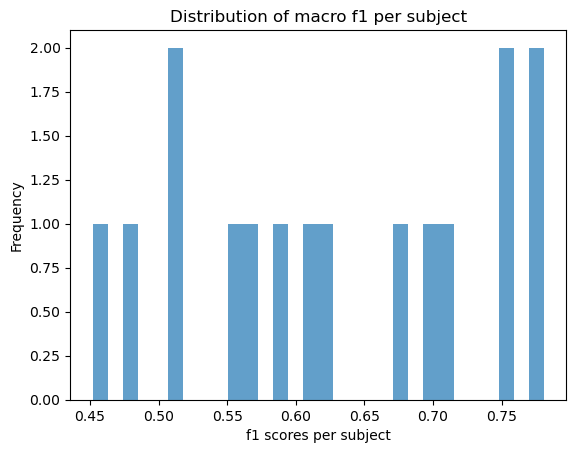

In [ ]:
val_df = info_val.copy()
val_df["y_true"] = y_val
val_df["y_pred"] = y_pred
scores = []
for sid, g in val_df.groupby("subject_id"):
    scores.append(f1_score(g.y_true, g.y_pred, average="macro"))
plt.hist(scores, bins=30, alpha=0.7)
plt.xlabel("f1 scores per subject")
plt.ylabel("Frequency")
plt.title("Distribution of macro F1 per subject")
plt.show()

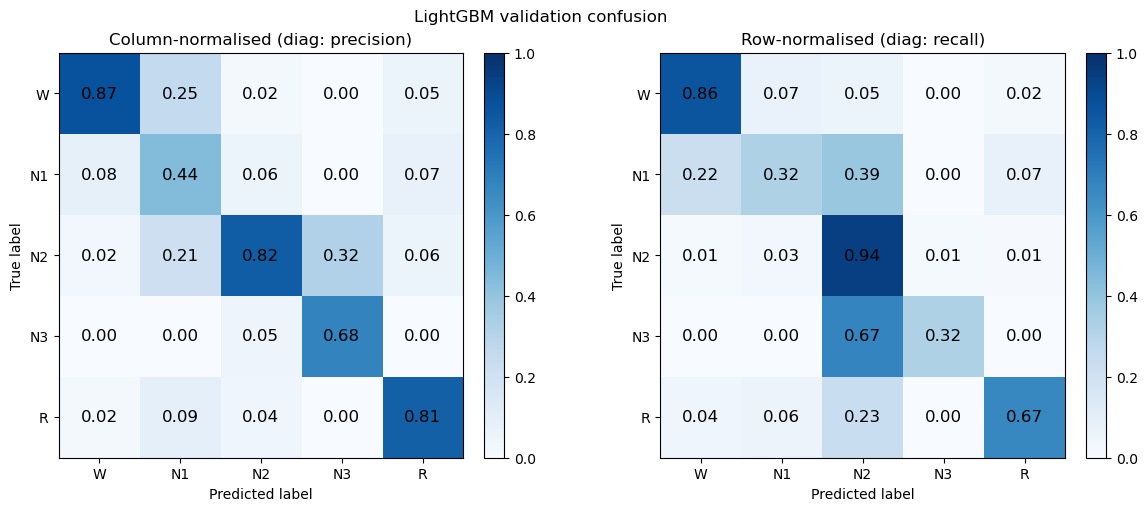

In [16]:
cm = {"confusion_matrix":confusion_matrix(y_val,y_pred_lgb)}
plot_confusion_matrix(cm, STAGE_MAP, title="LightGBM validation confusion")

The reason why N1 recall is low is because it is often mistaken as N2 (the dominant class) and W.

## post process: smoothing
mode filter for smoothing

In [9]:
best_xgb = globals().get("best_xgb", None)
best_lgb = globals().get("best_lgb", None)

if best_xgb is None:
    xgb_model_path = Path("../models/xgb_featured/model.json")
    if not xgb_model_path.exists():
        raise FileNotFoundError(f"XGBoost model not found: {xgb_model_path}")

    best_xgb = XGBClassifier()
    best_xgb.load_model(xgb_model_path)
    print(f"Loaded XGBoost from: {xgb_model_path}")

if best_lgb is None:
    lgb_model_path = Path("../models/lgb_featured/model.txt")
    if not lgb_model_path.exists():
        raise FileNotFoundError(f"LightGBM model not found: {lgb_model_path}")

    class _LGBBoosterWrapper:
        def __init__(self, booster):
            self.booster = booster

        def predict_proba(self, X):
            return self.booster.predict(X)

        def predict(self, X):
            return np.argmax(self.predict_proba(X), axis=1)

    best_lgb = _LGBBoosterWrapper(Booster(model_file=str(lgb_model_path)))
    print(f"Loaded LightGBM from: {lgb_model_path}")

Loaded XGBoost from: ../models/xgb_featured/model.json
Loaded LightGBM from: ../models/lgb_featured/model.txt


In [11]:
def mode_filter_1d(y, kernel_size=5):
    assert kernel_size % 2 == 1, "kernel_size must be odd"
    pad = kernel_size // 2
    y = np.asarray(y)
    y_pad = np.pad(y, (pad, pad), mode="edge")
    out = np.empty_like(y)

    for i in range(len(y)):
        window = y_pad[i:i + kernel_size]
        cnt = Counter(window)
        max_count = max(cnt.values())

        # tie-break: keep center label if tied
        candidates = [k for k, v in cnt.items() if v == max_count]
        center = y[i]
        out[i] = center if center in candidates else candidates[0]

    return out

In [12]:
y_pred_xgb = best_xgb.predict(X_val)
y_pred_lgb = best_lgb.predict(X_val)

y_pred_xgb_smooth = mode_filter_1d(y_pred_xgb, kernel_size=3)
print("XGBoost Val macro F1:", f1_score(y_val, y_pred_xgb_smooth, average="macro"))
print(classification_report(y_val, y_pred_xgb_smooth, digits=4, target_names=["W","N1","N2","N3","R"]))

y_pred_lgb_smooth = mode_filter_1d(y_pred_lgb, kernel_size=3)
print("LightGBM Val macro F1:", f1_score(y_val, y_pred_lgb_smooth, average="macro"))
print(classification_report(y_val, y_pred_lgb_smooth, digits=4, target_names=["W","N1","N2","N3","R"]))

XGBoost Val macro F1: 0.6733783433372408
              precision    recall  f1-score   support

           W     0.8789    0.8628    0.8708     18518
          N1     0.4664    0.3010    0.3659      6877
          N2     0.8254    0.9441    0.8808     38009
          N3     0.7606    0.3773    0.5044      3040
           R     0.8072    0.6917    0.7450      8097

    accuracy                         0.8141     74541
   macro avg     0.7477    0.6354    0.6734     74541
weighted avg     0.8010    0.8141    0.8007     74541

LightGBM Val macro F1: 0.6588600743444302
              precision    recall  f1-score   support

           W     0.8766    0.8600    0.8682     18518
          N1     0.4460    0.3163    0.3701      6877
          N2     0.8239    0.9406    0.8784     38009
          N3     0.6827    0.3227    0.4382      3040
           R     0.8189    0.6740    0.7394      8097

    accuracy                         0.8088     74541
   macro avg     0.7296    0.6227    0.6589     

## combine xgb and lgb

In [18]:
y_pred_xgb = best_xgb.predict_proba(X_val)
y_pred_lgb = best_lgb.predict_proba(X_val)

y_pred_comb = np.argmax(y_pred_xgb * 0.5 + y_pred_lgb * 0.5, axis=1)
print("Val macro F1:", f1_score(y_val, y_pred_comb, average="macro"))
print(classification_report(
    y_val, y_pred_comb, digits=4,
    target_names=["W", "N1", "N2", "N3", "R"]
))

Val macro F1: 0.6642536776299682
              precision    recall  f1-score   support

           W     0.8742    0.8598    0.8669     18518
          N1     0.4475    0.3089    0.3655      6877
          N2     0.8248    0.9398    0.8786     38009
          N3     0.7176    0.3536    0.4738      3040
           R     0.8085    0.6763    0.7365      8097

    accuracy                         0.8092     74541
   macro avg     0.7345    0.6277    0.6643     74541
weighted avg     0.7961    0.8092    0.7964     74541

